# Tilt effect in online chess (Lichess): data processing

**Research question (general).** Does the result of the previous game affect a player's behaviour and result in the next game of the same session?

This notebook covers **step 2 of the task** (sample construction, cleaning, preparation). Hypothesis testing is in the separate testing notebook.

### What the notebook does
1. Streams monthly Lichess dumps (`.pgn.zst`) without full decompression.
2. Parses **only the headers** of each game (the moves are not needed -> fast), plus the clocks to recover game duration.
3. Filters out: tournament/arena games, games involving bots, missing/zero ratings, self-play.
4. Splits each game into **two rows** (the White and the Black point of view).
5. Builds **sessions**: consecutive games by one player with the **exact same** time control and a real break (game end to next start) of at most the threshold.
6. Computes the expected score (Elo formula), the `shock` (deviation from expectation) and lag features.
7. Saves a compact table for statistical analysis.

### Session definition
A session is a run of consecutive games by one player, with the **exact same** time control, where the next game started no later than `SESSION_GAP_MINUTES` after the **end** of the previous one.

### Methodological warning
An "unexpected loss" is mechanically correlated with a rating drop and with regression to the mean. So to conclude anything about tilt we later compare the effect of an unexpected **loss** with that of an unexpected **win** (placebo / symmetry), rather than reading the raw "after a loss". We keep the signed `shock` in the dataset.

## 0. Configuration

In [1]:
import os, io, re, time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

DATA_DIR = "data"
OUT_DIR  = "processed"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Months from 2017 onward (with clocks). Download from https://database.lichess.org/standard/
MONTHS = ["2017-05"]

# A session breaks if the real gap (previous end -> next start) exceeds this many minutes.
SESSION_GAP_MINUTES = 5

# Speed categories to analyse (correspondence/ultrabullet dropped). None = keep all.
KEEP_SPEEDS = {"bullet", "blitz", "rapid"}

## 1. Download (on the server)
```bash
cd data
wget https://database.lichess.org/standard/lichess_db_standard_rated_2017-05.pgn.zst
```
The 2017 files are larger than 2016 (because of the clocks) but download quickly. One month is statistically more than enough.

In [2]:
def month_to_path(m):
    return os.path.join(DATA_DIR, f"lichess_db_standard_rated_{m}.pgn.zst")
for m in MONTHS:
    p = month_to_path(m)
    print(f"{m}: {os.path.getsize(p)/1e6:.0f} MB" if os.path.exists(p) else f"{m}: NOT FOUND")

2017-05: 3586 MB


## 2. Parsing: headers + game duration from the clocks
A `%clk` comment shows the remaining time AFTER a move (increment included). A player's time =
`base + inc*moves - last_remaining`. The game duration = White's time + Black's time, and the
game end = start + duration.

In [3]:
import zstandard as zstd

HEADER_RE = re.compile(r'^\[(\w+)\s+"(.*)"\]\s*$')
CLK_RE    = re.compile(r'\[%clk (\d+):(\d+):(\d+)\]')

def iter_games(text_stream):
    # Yields (headers dict, movetext str) per game.
    headers, moves, in_moves = {}, [], False
    for line in text_stream:
        line = line.rstrip("\n")
        if line.startswith("["):
            if in_moves and headers:          # headers of a new game start
                yield headers, " ".join(moves)
                headers, moves, in_moves = {}, [], False
            m = HEADER_RE.match(line)
            if m:
                headers[m.group(1)] = m.group(2)
        elif line == "":
            if in_moves and headers:
                yield headers, " ".join(moves)
                headers, moves, in_moves = {}, [], False
        else:
            in_moves = True
            moves.append(line)
    if headers and in_moves:
        yield headers, " ".join(moves)

def parse_tc(tc):
    if tc in ("-", "", None) or "+" not in tc:
        return None, None
    b, i = tc.split("+")
    try:    return int(b), int(i)
    except ValueError: return None, None

def game_duration_seconds(movetext, base, inc):
    # Game duration (seconds) from %clk. None if no clocks are present.
    if base is None:
        return None
    clks = [int(h)*3600+int(m)*60+int(s) for h,m,s in CLK_RE.findall(movetext)]
    if len(clks) < 2:
        return None
    wt = base + inc*len(clks[0::2]) - clks[0::2][-1]   # White's time
    bt = base + inc*len(clks[1::2]) - clks[1::2][-1]   # Black's time
    return max(wt + bt, 0)

def speed_category(tc):
    base, inc = parse_tc(tc)
    if base is None: return "correspondence"
    est = base + 40*inc
    if est < 30:   return "ultrabullet"
    if est < 180:  return "bullet"
    if est < 480:  return "blitz"
    if est < 1500: return "rapid"
    return "classical"

RESULT_SCORE = {"1-0": (1.0, 0.0), "0-1": (0.0, 1.0), "1/2-1/2": (0.5, 0.5)}

def parse_month(path, keep_speeds=None):
    # Parses one .pgn.zst -> DataFrame (2 rows per game) with a tqdm bar over file size.
    rows = []
    n_total = n_kept = 0
    fsize = os.path.getsize(path)
    with open(path, "rb") as fh, \
         tqdm(total=fsize, unit="B", unit_scale=True, desc=os.path.basename(path)) as bar:
        reader = zstd.ZstdDecompressor().stream_reader(fh)
        text = io.TextIOWrapper(reader, encoding="utf-8")
        last_pos = 0
        for h, movetext in iter_games(text):
            n_total += 1
            if n_total % 20000 == 0:                 # update the bar by position in the compressed file
                pos = fh.tell(); bar.update(pos - last_pos); last_pos = pos
            event = h.get("Event", "")
            if "tournament" in event.lower():                 continue   # drop tournaments/arenas
            if h.get("WhiteTitle") == "BOT" or h.get("BlackTitle") == "BOT": continue  # drop bots
            res = h.get("Result")
            if res not in RESULT_SCORE:                       continue
            try:    welo = int(h["WhiteElo"]); belo = int(h["BlackElo"])
            except (KeyError, ValueError):                    continue
            if welo <= 0 or belo <= 0:                        continue
            white, black = h.get("White"), h.get("Black")
            if not white or not black or white == black:      continue
            tc = h.get("TimeControl", "-")
            speed = speed_category(tc)
            if keep_speeds and speed not in keep_speeds:      continue
            base, inc = parse_tc(tc)
            dur = game_duration_seconds(movetext, base, inc)  # seconds or None
            date = h.get("UTCDate", h.get("Date", "")); utct = h.get("UTCTime", "00:00:00")
            term = h.get("Termination", "")
            try:    wdiff = int(h.get("WhiteRatingDiff","0").replace("+",""))
            except ValueError: wdiff = 0
            try:    bdiff = int(h.get("BlackRatingDiff","0").replace("+",""))
            except ValueError: bdiff = 0
            ws, bs = RESULT_SCORE[res]
            n_kept += 1
            rows.append((white, black, "white", welo, belo, ws, wdiff, date, utct, tc, speed, term, dur))
            rows.append((black, white, "black", belo, welo, bs, bdiff, date, utct, tc, speed, term, dur))
        bar.update(fsize - last_pos)
    cols = ["player","opponent","color","player_elo","opp_elo","score","rating_diff",
            "date","utctime","tc","speed","termination","duration_s"]
    df = pd.DataFrame.from_records(rows, columns=cols)
    print(f"  {n_total:,} games -> kept {n_kept:,} ({n_kept/max(n_total,1):.1%}); "
          f"{len(df):,} rows; without clocks: {df['duration_s'].isna().mean():.1%}")
    return df

## 3. Process the months -> compact parquet

In [4]:
def shrink_dtypes(df):
    df["player_elo"]  = df["player_elo"].astype("int16")
    df["opp_elo"]     = df["opp_elo"].astype("int16")
    df["rating_diff"] = df["rating_diff"].astype("int16")
    df["score"]       = df["score"].astype("float32")
    df["duration_s"]  = df["duration_s"].astype("float32")
    for c in ["color","tc","speed","termination"]:
        df[c] = df[c].astype("category")
    return df

for m in MONTHS:
    out = os.path.join(OUT_DIR, f"rows_{m}.parquet")
    if os.path.exists(out):
        print(f"{m}: already done"); continue
    p = month_to_path(m)
    if not os.path.exists(p):
        print(f"{m}: file not found"); continue
    print(f"Parsing {m} ...")
    shrink_dtypes(parse_month(p, keep_speeds=KEEP_SPEEDS)).to_parquet(out)

Parsing 2017-05 ...


lichess_db_standard_rated_2017-05.pgn.zst:   0%|          | 0.00/3.59G [00:00<?, ?B/s]

  11,693,919 games -> kept 9,306,961 (79.6%); 18,613,922 rows; without clocks: 0.0%


## 4. Concatenate months, build start and end times

In [5]:
parts = [pd.read_parquet(os.path.join(OUT_DIR, f"rows_{m}.parquet"))
         for m in MONTHS if os.path.exists(os.path.join(OUT_DIR, f"rows_{m}.parquet"))]
df = pd.concat(parts, ignore_index=True); del parts

df["ts"] = pd.to_datetime(df["date"] + " " + df["utctime"],
                          format="%Y.%m.%d %H:%M:%S", utc=True, errors="coerce")
df = df.dropna(subset=["ts"]).drop(columns=["date","utctime"])
# Game end = start + duration. If clocks were missing, end = start (the gap becomes start-to-start).
df["end_ts"] = df["ts"] + pd.to_timedelta(df["duration_s"].fillna(0), unit="s")

df["player"]   = df["player"].astype("category")
df["opponent"] = df["opponent"].astype("category")

print(f"Player-game rows: {len(df):,} | players: {df['player'].nunique():,} | "
      f"memory: {df.memory_usage(deep=True).sum()/1e6:.0f} MB")
print("Median game duration by speed (seconds):")
print(df.groupby('speed', observed=True)['duration_s'].median())

Player-game rows: 18,613,922 | players: 207,812 | memory: 808 MB
Median game duration by speed (seconds):
speed
blitz     326.0
bullet    109.0
rapid     609.0
Name: duration_s, dtype: float32


## 5. Build sessions by the REAL break
The break = start of the current game minus the **end** of the player's previous game. A session breaks if the
gap exceeds `SESSION_GAP_MINUTES`, or the time control changes, or the player changes.

In [ ]:
df = df.sort_values(["player","ts"]).reset_index(drop=True)

prev_player  = df["player"].shift()
prev_tc      = df["tc"].shift()
prev_end     = df["end_ts"].shift()
gap_min      = (df["ts"] - prev_end).dt.total_seconds() / 60.0   # end-to-start break

new_session = (
    (df["player"].values != prev_player.values) |
    (df["tc"].values != prev_tc.values) |
    (gap_min > SESSION_GAP_MINUTES).values |
    (gap_min.isna()).values
)
df["session_id"]         = new_session.cumsum()
df["gap_from_prev_min"]  = gap_min.where(~new_session).astype("float32")
df["game_no_in_session"] = df.groupby("session_id").cumcount().astype("int32") + 1
print(f"Sessions: {df['session_id'].nunique():,}")

Sessions: 7,242,088
Share of negative gaps (overlapping games, should be ~0): 0.1234%


## 6. Expected score, shock, lag features

In [7]:
df["expected"]  = (1.0/(1.0+10**((df["opp_elo"]-df["player_elo"])/400.0))).astype("float32")
df["adj_score"] = (df["score"]-df["expected"]).astype("float32")   # >0 = better than expected
df["shock"]     = (df["expected"]-df["score"]).astype("float32")   # >0 = underperformed (worse than expected)

gs = df.groupby("session_id")
df["prev_score"]    = gs["score"].shift().astype("float32")
df["prev_expected"] = gs["expected"].shift().astype("float32")
df["prev_shock"]    = gs["shock"].shift().astype("float32")
df["prev_adj"]      = gs["adj_score"].shift().astype("float32")
df["prev_opponent"] = gs["opponent"].shift()
df["prev_result"]   = pd.cut(df["prev_score"], [-0.1,0.25,0.75,1.1], labels=["loss","draw","win"])
df["prev_loss"]     = (df["prev_score"]==0.0).astype("float32")
df["is_rematch"]    = (df["opponent"].astype(str)==df["prev_opponent"].astype(str)).astype("float32")
df["is_last_in_session"] = (gs.cumcount(ascending=False)==0).astype("int8")
print("Done.")

Done.


## 7. How much data (for section 2 of the report)

In [8]:
n_sessions   = df["session_id"].nunique()
n_transitions = int(df["prev_result"].notna().sum())
print(f"Player-game rows:        {len(df):,}")
print(f"Distinct players:        {df['player'].nunique():,}")
print(f"Sessions:                {n_sessions:,}")
print(f"Transitions (for regr.): {n_transitions:,}")
sess_len = df.groupby("session_id").size()
print(f"\nSession length: median={sess_len.median():.0f}, mean={sess_len.mean():.2f}, "
      f"95%={sess_len.quantile(0.95):.0f}, max={sess_len.max()}")
print("Share of sessions of length 1..5+:")
print(sess_len.clip(upper=5).value_counts(normalize=True).sort_index().to_string())
print("\nTransitions by previous outcome:")
print(df["prev_result"].value_counts(dropna=True).to_string())

Player-game rows:        18,613,922
Distinct players:        207,812
Sessions:                7,242,088
Transitions (for regr.): 11,371,834

Session length: median=1, mean=2.57, 95%=8, max=374
Share of sessions of length 1..5+:
1    0.545369
2    0.185727
3    0.091989
4    0.052589
5    0.124326

Transitions by previous outcome:
prev_result
win     5699864
loss    5220171
draw     451799


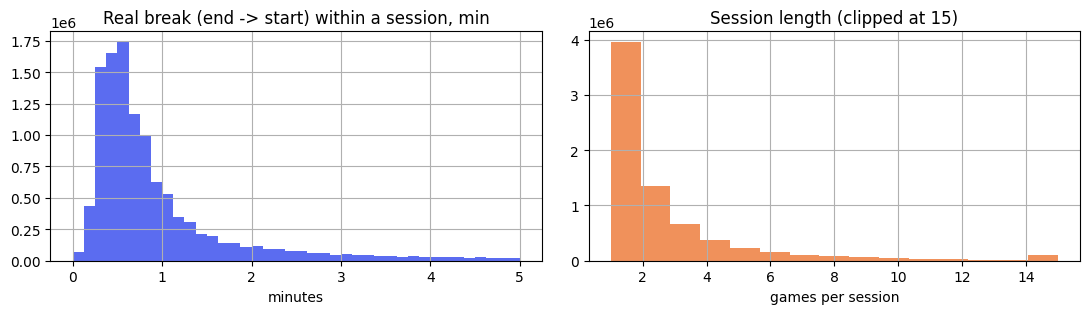

saved: fig_sample_overview.png


In [9]:
import matplotlib; import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
df.loc[df["gap_from_prev_min"].notna(),"gap_from_prev_min"].clip(lower=0, upper=SESSION_GAP_MINUTES)\
  .hist(bins=40, ax=ax[0], color="#5b6cf0")
ax[0].set_title("Real break (end -> start) within a session, min"); ax[0].set_xlabel("minutes")
sess_len.clip(upper=15).hist(bins=15, ax=ax[1], color="#f0915b")
ax[1].set_title("Session length (clipped at 15)"); ax[1].set_xlabel("games per session")
plt.tight_layout(); plt.savefig("fig_sample_overview.png", dpi=110); plt.show()
print("saved: fig_sample_overview.png")

## 8. Save the compact analysis table

In [11]:
keep = ["player","opponent","session_id","game_no_in_session","ts","end_ts","duration_s",
        "tc","speed","color","player_elo","opp_elo","rating_diff",
        "score","expected","adj_score","shock",
        "prev_result","prev_loss","prev_shock","prev_adj","is_rematch",
        "gap_from_prev_min","is_last_in_session"]
analysis = df[keep].copy()
out_path = os.path.join(OUT_DIR, f"analysis_{'_'.join(MONTHS)}.parquet")
analysis.to_parquet(out_path)
print(f"Saved: {out_path} | rows: {len(analysis):,} | "
      f"{analysis.memory_usage(deep=True).sum()/1e6:.0f} MB")

Saved: processed/analysis_2017-05.parquet | rows: 18,613,922 | 1645 MB
